In [79]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

import matplotlib.colors as mcolors
import matplotlib as mpl

from sklearn.metrics import silhouette_score

import networkx as nx
import community as community_louvain

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [3]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [4]:
import geopandas as gpd
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world_url = gpd.read_file(url)

In [5]:
df_map_analysis = pd.read_csv(uf.PATH+"df_map_analysis.csv").dropna(subset="cluster")

In [6]:
df_map_analysis.dropna(subset="cluster")

,year,country,cluster
37,1975,AR,8.0
38,1975,AT,0.0
39,1975,AU,7.0
40,1975,BE,5.0
41,1975,BG,4.0
...,...,...,...
3890,2023,VN,32.0
3891,2023,YE,13.0
3892,2023,ZA,32.0
3893,2023,ZM,24.0


# Utilities

In [7]:
# df_baricenter_yearly_list = []

# year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

# for year_loop in year_list:
#     country_list = df_map_analysis.query("year == @year_loop").country.to_list()
#     df_prob = df_prob_yearly.xs(year_loop, level=1).loc[country_list]
#     # print(df_prob["3002"])
#     df_baricenter_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    
# df_baricenter_global_yearly = pd.concat(df_baricenter_yearly_list, axis=1).T

In [8]:
# df_baricenter_global_yearly.to_csv(uf.PATH+"df_barycenter_global_yearly.csv")
df_baricenter_global_yearly = pd.read_csv(uf.PATH+"df_barycenter_global_yearly.csv", index_col=0)

In [9]:
uf.plotly_heatmap(df_baricenter_global_yearly, df_baricenter_global_yearly.columns, df_baricenter_global_yearly.index,
                  colorscale="non", z_min=0, z_max=0.02, line_height=10, x_type="subfield")

In [10]:
cluster_list = df_map_analysis.cluster.drop_duplicates().sort_values().to_list()
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [11]:
profile_yearly_list = []
for cluster_loop in cluster_list:
    cluster_year_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()
    cluster_profile_yearly_list = []
    for year_loop in cluster_year_list:
        cluster_country_list = df_map_analysis.query("cluster == @cluster_loop and year == @year_loop").country.drop_duplicates().sort_values().to_list()
        if cluster_country_list == []:
            print(year_loop, cluster_loop)
            continue
        # print(cluster_country_list)
        df_prob = df_prob_yearly.xs(year_loop, level=1).loc[cluster_country_list]
        cluster_profile_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    # print(cluster_profile_yearly_list)
    if cluster_profile_yearly_list == []:
        print(year_loop, cluster_loop)
        continue
    profile_yearly_list.append(pd.concat(cluster_profile_yearly_list, axis=1).T.assign(cluster=cluster_loop))
df_profile_yearly = pd.concat(profile_yearly_list).reset_index(names="year").set_index(["cluster", "year"])

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1284: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1284: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1284: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [12]:
df_profile_yearly.to_csv(uf.PATH+"df_profile_by_cluster.csv")
# df_profile_yearly = pd.read_csv(uf.PATH+"df_profile_by_cluster.csv", index_col=[0, 1])

In [13]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_neighbours_counts = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)

# df_n_years = pd.DataFrame(
#     co_membership,
#     index=pivot.index,
#     columns=pivot.index
# )
# df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# # df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [704]:
# uf.plotly_heatmap(df_baricenter_global_yearly,
#                   x_labels=df_baricenter_global_yearly.columns,
#                   y_labels=df_baricenter_global_yearly.index,
#                   colorscale="non",
#                   z_min=0, z_max=0.02,
#                   line_height=10,
#                   x_type="subfield")

# Country overview

In [705]:
uf.id2name_country["DZ"]

'Algeria'

In [706]:
country = "DZ"

year_list = df_map_analysis.query("country == @country").year.drop_duplicates().sort_values().to_list()
country_clusters = df_map_analysis.query("country == @country").cluster.drop_duplicates().sort_values().to_list()

In [ ]:
df_profile_country = df_prob_yearly.xs(country, level=0).loc[year_list]

In [ ]:
uf.plotly_heatmap(df_profile_country, x_labels=df_profile_country.columns, y_labels=year_list, colorscale="non", z_min=0, z_max=0.02, line_height=10, title=country)

In [ ]:
cmap = plt.get_cmap("viridis")

In [ ]:
df_gl = (
    df_baricenter_global_yearly
    .loc[year_list]
    .apply(uf.gini, axis=1)
    .to_frame("global")
)
df_cl = (
    df_map_analysis
    .query("country == @country")
    .merge(df_profile_yearly, left_on=["cluster", "year"], right_index=True, how="left")
    .drop(columns=["country", "cluster"])
    .set_index("year")
    .apply(uf.gini, axis=1)
    .to_frame("cluster")
)

df_c = (
    df_profile_country
    .apply(uf.gini, axis=1)
    .to_frame(country)
)

df_gini = pd.concat([df_gl, df_cl, df_c], axis=1)

In [ ]:
cluster_list = df_map_analysis.query("country == @country").cluster.drop_duplicates().to_list()
cluster_labels = dict(zip(cluster_list ,["Cluster "+str(cl) if cluster_list[cl-1] != 0 else "Undefined" for cl in range(1, len(cluster_list)+1)]))
cluster_colors = dict(zip(cluster_list, cmap(np.linspace(0, 1, len(cluster_labels)))))

In [ ]:
import itertools

year_cluster = dict(zip(df_map_analysis.query("country == @country")[["year", "cluster"]].drop_duplicates().year,
                        df_map_analysis.query("country == @country")[["year", "cluster"]].drop_duplicates().cluster))

segments = []
for cluster, group in itertools.groupby(year_cluster.items(), key=lambda x: x[1]):
    years = [y for y, _ in group]
    segments.append((min(years), max(years), cluster))

In [ ]:
import matplotlib.patches as mpatches

cluster_handles = [
    mpatches.Patch(color=color, alpha=0.2, label=cluster)
    for cluster, color in cluster_colors.items()
]

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))

# --- background shading ---
for start, end, cluster in segments:
    ax.axvspan(
        start,
        end + 1,
        color=cluster_colors[cluster],
        alpha=0.2
    )

# --- lines ---
line1, = ax.plot(df_gl.index, df_gl.values, label="Global", color="grey")
line2, = ax.plot(df_cl.index, df_cl.values, label="Cluster", color="grey", linestyle="--")
line3, = ax.plot(df_c.index, df_c.values, label=uf.id2name_country[country], color="red")

# --- legends ---
line_legend = ax.legend(loc="upper left")   # for lines
ax.add_artist(line_legend)                 # keep it

cluster_legend = ax.legend(
    handles=cluster_handles,
    title="Clusters",
    loc="upper right"
)

ax.grid(alpha=0.3)
_ = ax.set_title("Gini of the profile")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 1, 5, 10, 15, 20]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# --- 2. Prepare data ---
df_plot_neighbours = (
    df_neighbours_counts
    .loc[country]
    .sort_values(ascending=False)
    .to_frame("years")
    .merge(
        uf.df_country[["alpha-2", "alpha-3"]],
        left_index=True,
        right_on="alpha-2",
        how="left"
    )
)

# --- 3. Create categorical variable ---
df_plot_neighbours["years_category"] = pd.cut(
    df_plot_neighbours["years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- 4. Merge with world map ---
world = world_url.merge(
    df_plot_neighbours,
    left_on="ISO_A3",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="years_category",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Neighbour metric (binned): {country}")

plt.show()

# Cluster overview

In [ ]:
cluster = 18
# 5, 17, 18

In [ ]:
years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
years_list_full = range(years_list[0], years_list[-1]+1)

In [ ]:
df_years = pd.DataFrame({}, index=years_list_full)
df_years.loc[years_list] = 1

In [ ]:
total_countries = len(pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs((2023, "individual"), level=[1, 2]).index)

df_pct_country = (
    pd.concat([
        df_map_analysis.query("year == @years_list and cluster == @cluster").groupby("year").country.count().to_frame("cluster"),
        df_map_analysis.query("year == @years_list").groupby("year").country.count().to_frame("all")
    ], axis=1)
    .assign(
        share_cluster = lambda df: df.cluster / total_countries,
        share_other = lambda df: (df.eval("all - cluster")) / total_countries)
)
# df_pct_country

In [ ]:
df_pct_articles = (
    df_cs_yearly
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"])
    .drop(columns=["country", "cluster"])
    .groupby(["year"])
    .sum()
    .sum(axis=1)
    .to_frame("share_cluster")
    .div(df_cs_yearly.sum(axis=1).groupby(level=1).sum().loc[years_list], axis=0)
    .assign(share_other = lambda df: 1 - df.share_cluster)
)
# df_pct_articles

In [ ]:
bins = [0, 0.10, 0.50, 0.90, 1]
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(len(bins) - 1)]

df_cluster_country_count = (
    df_map_analysis
    .query("cluster == @cluster")
    .groupby("country", as_index=False)
    .year
    .count()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .assign(
        year_share = lambda df: df.year / len(years_list),
        year_cat = lambda df: pd.cut(
                                    df["year_share"],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True
                                )
    )
)
# df_cluster_country_count

In [ ]:
df_gini_profiles = pd.concat([
    df_baricenter_global_yearly.loc[years_list].apply(uf.gini, axis=1).to_frame("all"),
    df_profile_yearly.xs(cluster, level=0).apply(uf.gini, axis=1).to_frame("cluster")
], axis=1)

In [ ]:
df_gini_countries = pd.concat([(
    df_cs_yearly.sum(axis=1).to_frame("total")
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"], how="right")
    .groupby("year")
    .total
    .agg(uf.gini)
    .to_frame("cluster")
), df_cs_yearly.sum(axis=1).groupby(level=1).agg(uf.gini).to_frame("all").loc[years_list]], axis=1)

In [ ]:
df_domains = (
    df_profile_yearly
    .xs(cluster, level=0)
    .T
    .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_id_str=lambda df: df.subfield_id.astype(str)),
           left_index=True, right_on="subfield_id_str")
    .drop(columns=["subfield_id", "subfield_id_str"])
    .groupby("domain_name")
    .sum()
    .T
    # .sum()
)

In [ ]:
df_spec = (
    df_profile_yearly.xs(cluster, level=0)
    .sub(df_baricenter_global_yearly.loc[years_list])
    # .div(df_std_yearly.T.loc[df_baricenter_global_yearly.columns].T.loc[years_list])
)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))

x = df_pct_country.index
y1 = df_pct_country["share_cluster"]
y2 = df_pct_country["share_other"]

ax.stackplot(x, y1, y2, labels=["Cluster", "Other"], alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("N countries Share")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_pct_articles.index
y1 = df_pct_articles["share_cluster"]
y2 = df_pct_articles["share_other"]

ax.stackplot(x, y1, y2, labels=["Cluster", "Other"], alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("N articles Share")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_domains.index.astype(int)
y1 = df_domains[df_domains.columns[0]]
y2 = df_domains[df_domains.columns[1]]
y3 = df_domains[df_domains.columns[2]]
y4 = df_domains[df_domains.columns[3]]

ax.stackplot(x, y1, y2, y3, y4, labels=df_domains.columns, alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("Share articles by domain")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# --- 4. Merge with world map ---
world = world_url.merge(
    df_cluster_country_count,
    left_on="ISO_A3",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="year_cat",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Countries in cluster {cluster}")

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.plot(df_gini_countries.index, df_gini_countries.cluster, label="Cluster")
plt.plot(df_gini_countries.index, df_gini_countries["all"], label="Global")
plt.grid(alpha=0.3)
plt.ylabel("Gini")
plt.legend()
_ = plt.title("Gini coefficient by countries productivity")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.plot(df_gini_profiles.index, df_gini_profiles.cluster, label="Cluster")
plt.plot(df_gini_profiles.index, df_gini_profiles["all"], label="Global")
plt.grid(alpha=0.3)
plt.ylabel("Gini")
plt.legend()
_ = plt.title("Gini coefficient by subfield profiles")

In [ ]:
uf.plot_heatmap(df_spec, df_spec.columns, df_spec.index, line_height=10,
                # x_type="subfield",
                z_min=-0.02, z_max=0.02)

# Year overview

# All years clusters

In [707]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

In [708]:
import plotly.express as px

fig = px.area(
    df_stats_cluster.replace({0: np.nan}),
    x="year",
    y="countries_share",
    color="cluster",
    title="Cluster share over time (countries)"
)

fig.update_layout(
    yaxis_range=[0, 1],
    xaxis_title="Year",
    yaxis_title="Share"
)

fig.show()

In [709]:
all_clusters = df_map_analysis.cluster.drop_duplicates().sort_values().to_list()

In [710]:
spec_domain_list = []
for cluster_loop in all_clusters:
    tmp = (
        df_profile_yearly
        .xs(cluster_loop, level=0)
        .T
        .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_id_str=lambda df: df.subfield_id.astype(str)),
            left_index=True, right_on="subfield_id_str")
        .drop(columns=["subfield_id", "subfield_id_str"])
        .groupby("domain_name")
        .sum()
        .T
        .mean()
        .sort_values()
    )
    spec_domain_list.append(
        {
            "cluster": cluster_loop,
            "domain": tmp.index[-1],
            "prob": tmp.iloc[-1]
        }
    )

In [711]:
domain = "Physical Sciences"
df_cluster_domain = pd.json_normalize(spec_domain_list).query("cluster > 0").sort_values(["domain", "prob"]).reset_index(drop=True)

In [712]:
df_cluster_test = (
    df_cluster_domain
    .assign(new_cluster = lambda df: [i + 1 for i in df.index])
)

In [713]:
cmap_clusters = plt.get_cmap("tab20b")

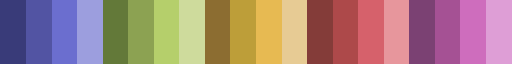

In [714]:
cmap_clusters

In [715]:
cmap_clusters(0)

(np.float64(0.2235294117647059),
 np.float64(0.23137254901960785),
 np.float64(0.4745098039215686),
 np.float64(1.0))

In [716]:
df_cluster_test[["cluster", "new_cluster"]].set_index("cluster").to_dict()["new_cluster"]

{31.0: 1,
 8.0: 2,
 19.0: 3,
 17.0: 4,
 14.0: 5,
 7.0: 6,
 13.0: 7,
 27.0: 8,
 32.0: 9,
 22.0: 10,
 29.0: 11,
 23.0: 12,
 15.0: 13,
 25.0: 14,
 26.0: 15,
 28.0: 16,
 10.0: 17,
 30.0: 18,
 21.0: 19,
 5.0: 20,
 11.0: 21,
 20.0: 22,
 12.0: 23,
 4.0: 24,
 9.0: 25,
 33.0: 26,
 16.0: 27,
 18.0: 28,
 24.0: 29}

In [717]:
color_dict_cluster_mpl = {
    -1: "white",
    # undefined
    0: "grey",
    # social (small to big)
    14: cmap_clusters(3), 
    15: cmap_clusters(2),
    16: cmap_clusters(1),
    17: cmap_clusters(0),
    # health
    1: cmap_clusters(5),
    #phys small
    2: cmap_clusters(11),
    3: cmap_clusters(10), 
    4: cmap_clusters(9), 
    5: cmap_clusters(8),
    # phys medium
    6: cmap_clusters(15),
    7: cmap_clusters(14),
    8: cmap_clusters(13),
    9: cmap_clusters(12),
    # phys strong
    10: cmap_clusters(19),
    11: cmap_clusters(18), 
    12: cmap_clusters(17), 
    13: cmap_clusters(16)

}

names_dict_cluster = {
    -1: "Not in analysis",
    # undefined
    0: "Undetermined",
    # social (small to big)
    14: "Social 1", 
    15: "Social 2",
    16: "Social 3",
    17: "Social 4",
    # health
    1: "Health 1",
    #phys small
    2: "Physical Small 1",
    3: "Physical Small 2", 
    4: "Physical Small 3", 
    5: "Physical Small 4",
    # phys medium
    6: "Physical Medium 1",
    7: "Physical Medium 2",
    8: "Physical Medium 3",
    9: "Physical Medium 4",
    # phys strong
    10: "Physical Strong 1",
    11: "Physical Strong 2", 
    12: "Physical Strong 3", 
    13: "Physical Strong 4"

}

0.28853999000239333
0.40766781358755044


KeyError: 1

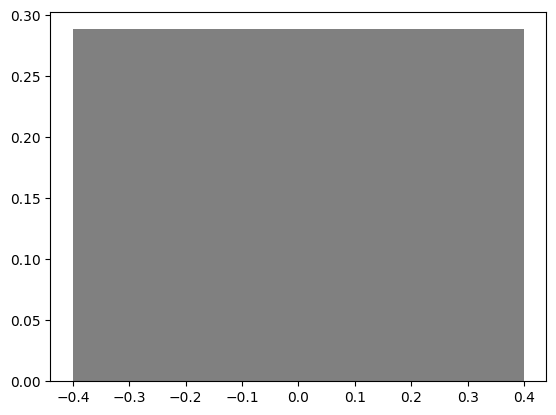

In [718]:
for i, cluster in enumerate(df_cluster_domain.index):
    print(df_cluster_domain.loc[cluster].prob)
    plt.bar(i, df_cluster_domain.loc[cluster].prob, color=color_dict_cluster[cluster])

In [ ]:
cluster_to_idx = {c: i for i, c in enumerate(clusters)}

year = 2023
y_label = df_map_analysis_upd.query("year == @year").sort_values(["cluster"], ascending=False).country.to_list()

df_plot = (
    df_map_analysis_upd
    # .query("cluster == @cluster")
    # .assign(cluster_str=lambda df: df.cluster.astype(str))
    .pivot(index="country", columns="year", values="cluster")
    .loc[y_label]
    # .replace({cluster: 1})
    # .fillna(0)
)

# df_plot_mapped = df_plot.replace(cluster_to_idx)

In [ ]:
df_plot.fillna(-1)

In [ ]:
import numpy as np
import plotly.graph_objects as go

# --- map clusters to indices ---
clusters = sorted(color_dict_cluster.keys())
cluster_to_idx = {c: i for i, c in enumerate(clusters)}

df_plot_mapped = df_plot.replace(cluster_to_idx)

# --- handle NaNs ---
df_plot_mapped = df_plot_mapped.fillna(-1)

# add color for missing
color_dict_cluster[-1] = "white"
clusters = [-1] + clusters

# --- rebuild mapping ---
cluster_to_idx = {c: i for i, c in enumerate(clusters)}
df_plot_mapped = df_plot.replace(cluster_to_idx).fillna(0)

z = df_plot_mapped.values
n = len(clusters)

# --- colorscale ---
colorscale = []
def to_plotly_color(c):
    if isinstance(c, str):
        return c
    r, g, b, a = c
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{a})"

color_dict_cluster = {
    k: to_plotly_color(v)
    for k, v in color_dict_cluster.items()
}
for i, c in enumerate(clusters):
    v0 = i / (n - 1)
    v1 = i / (n - 1) if i == n - 1 else (i + 1) / (n - 1)
    
    colorscale.append((v0, color_dict_cluster[c]))
    colorscale.append((v1, color_dict_cluster[c]))

# --- plot ---
fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=df_plot.columns,
        y=df_plot.index,
        colorscale=colorscale,
        zmin=0,
        zmax=n - 1,
        showscale=False
    )
)

fig.update_layout(
    height=800,
    yaxis=dict(autorange="reversed")
)

for c in clusters:
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(size=10, color=color_dict_cluster[c]),
            legendgroup=str(c),
            showlegend=True,
            name=names_dict_cluster[c]
        )
    )

fig.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import plotly.express as px
# import matplotlib.colors as mcolors

# # --- 1. Ensure clusters are integers ---
# df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# # --- 2. Convert matplotlib colors → Plotly ---
# def to_plotly_color(c):
#     if isinstance(c, str):
#         return c
#     r, g, b, a = mcolors.to_rgba(c)
#     return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{a})"

# color_dict_cluster_plotly = {
#     k: to_plotly_color(v)
#     for k, v in color_dict_cluster.items()
# }

# # --- 3. Replace cluster IDs with names (for legend) ---
# df_plot_area = df_stats_cluster.copy()

# df_plot_area["cluster_name"] = df_plot_area["cluster"].map(names_dict_cluster)

# # handle undefined if needed
# df_plot_area["cluster_name"] = df_plot_area["cluster_name"].fillna("Undefined")

# # --- 4. Build color map with names as keys ---
# color_map_named = {
#     names_dict_cluster[k]: color_dict_cluster_plotly[k]
#     for k in color_dict_cluster
# }

# # ensure Undefined exists
# color_map_named["Undefined"] = "lightgrey"

# # --- 5. Define order (important for stacked area) ---
# cluster_order = [
#     names_dict_cluster[k]
#     for k in sorted(names_dict_cluster.keys())
#     if k != 0
# ]

# cluster_order = ["Undefined"] + cluster_order

# # --- 6. Plot ---
# fig = px.area(
#     df_plot_area,
#     x="year",
#     y="countries_share",
#     color="cluster_name",
#     color_discrete_map=color_map_named,
#     category_orders={"cluster_name": cluster_order},
#     title="Cluster share over time (countries)"
# )

# # --- 7. Layout ---
# fig.update_layout(
#     yaxis_range=[0, 1],
#     xaxis_title="Year",
#     yaxis_title="Share",
#     legend_title="Cluster",
#     hovermode="x unified"
# )

# fig.show()

In [509]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. Ensure clusters are integers ---
df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# --- 2. Convert colors (matplotlib already OK, but normalize anyway) ---
# def to_mpl_color(c):
#     if isinstance(c, str):
#         return c
#     return mcolors.to_rgba(c)

# color_dict_cluster_mpl = {
#     k: to_mpl_color(v)
#     for k, v in color_dict_cluster.items()
# }

# --- 3. Add cluster names ---
df_plot = df_stats_cluster.copy()
df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# --- 4. Build color map with names ---
color_map_named = {
    names_dict_cluster[k]: color_dict_cluster_mpl[k]
    for k in color_dict_cluster
}
color_map_named["Undefined"] = "lightgrey"

# --- 5. Pivot to wide format ---
df_wide = (
    df_plot
    .pivot(index="year", columns="cluster_name", values="countries_share")
    .fillna(0)
)

# --- 6. Define consistent order ---
cluster_order = [
    names_dict_cluster[k]
    for k in sorted(names_dict_cluster.keys())
    if k != 0
]
cluster_order = ["Undefined"] + cluster_order

# keep only existing columns
cluster_order = [c for c in cluster_order if c in df_wide.columns]

df_wide = df_wide[cluster_order]

# --- 7. Plot stacked area ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.stackplot(
    df_wide.index,
    df_wide.T.values,
    labels=df_wide.columns,
    colors=[color_map_named[c] for c in df_wide.columns]
)

# --- 8. Styling ---
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Share")
ax.set_title("Cluster share over time (countries)")

ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'names_dict_cluster' is not defined

In [ ]:
df_map_analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

year = 2023
y_label = (
    df_map_analysis_upd
    .merge(df_cs_yearly.sum(axis=1).to_frame("total"), left_on=["country", "year"], right_index=True)
    .query("year == @year").sort_values(["cluster", "total"], ascending=False)
    .country
    .to_list()
)

df_plot = (
    df_map_analysis_upd
    .pivot(index="country", columns="year", values="cluster")
    .loc[y_label]
)

# --- 1. Map clusters to indices ---
clusters = sorted(color_dict_cluster_mpl.keys())
clusters_with_missing = [-1] + clusters

color_list = [
    color_dict_cluster_mpl[c]
    for c in clusters_with_missing
]
cmap = mcolors.ListedColormap(color_list)

# --- 5. Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 20))

im = ax.imshow(
    df_plot.fillna(-1).values,
    aspect="auto",
    cmap=cmap,
)

# --- 6. Axis labels ---
ax.set_xticks(range(len(df_plot.columns)))
ax.set_xticklabels(df_plot.columns, rotation=90)

ax.set_yticks(range(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

ax.set_title("Cluster Heatmap")

from matplotlib.patches import Patch

legend_elements = []

for c in clusters_with_missing:
    legend_elements.append(Patch(facecolor=color_dict_cluster_mpl[c], label=names_dict_cluster[c]))

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    fontsize=10
)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
# ax.grid(axis="y", linestyle="-", linewidth=0.5, color="white")


n_rows, n_cols = df_plot.shape
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", axis="y", color="white", linewidth=1)
ax.tick_params(which="minor", left=False)


plt.tight_layout()
plt.show()

In [ ]:
df_sf = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])

ordered_subfields = df_sf.subfield_id.astype(str).to_list()
df_sf

# Define dominance

In [18]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

In [19]:
year = 2023
df_map_analysis.query("year == @year")

,year,country,cluster
3752,2023,AE,32.0
3753,2023,AF,24.0
3754,2023,AL,24.0
3755,2023,AM,32.0
3756,2023,AO,24.0
...,...,...,...
3890,2023,VN,32.0
3891,2023,YE,13.0
3892,2023,ZA,32.0
3893,2023,ZM,24.0


In [33]:
df_sf = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])

ordered_subfields = df_sf.subfield_id.astype(str).to_list()
all_clusters = df_map_analysis.cluster.drop_duplicates().to_list()

In [34]:
cluster = 17

years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
years_list_full = range(years_list[0], years_list[-1]+1)

df_cluster_profile = df_profile_yearly.xs(cluster, level=0)[ordered_subfields]
df_plot = (
    df_cluster_profile[ordered_subfields]
    .sub(df_baricenter_global_yearly.loc[df_cluster_profile.index, ordered_subfields])
    .div(df_prob_yearly.std())
)

In [35]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [36]:
# year = 2010
# cluster_countries = df_map_analysis.query("cluster == @cluster and year == @year").country.to_list()
# uf.get_w1_barycenter(df_prob_yearly.xs(year, level=1).loc[cluster_countries])

In [37]:
bins = [0, 0.10, 0.50, 0.90, 1]
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(len(bins) - 1)]

df_cluster_country_count = (
    df_map_analysis
    .query("cluster == @cluster")
    .groupby("country", as_index=False)
    .year
    .count()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .assign(
        year_share = lambda df: df.year / len(years_list),
        year_cat = lambda df: pd.cut(
                                    df["year_share"],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True
                                )
    )
)
# df_cluster_country_count

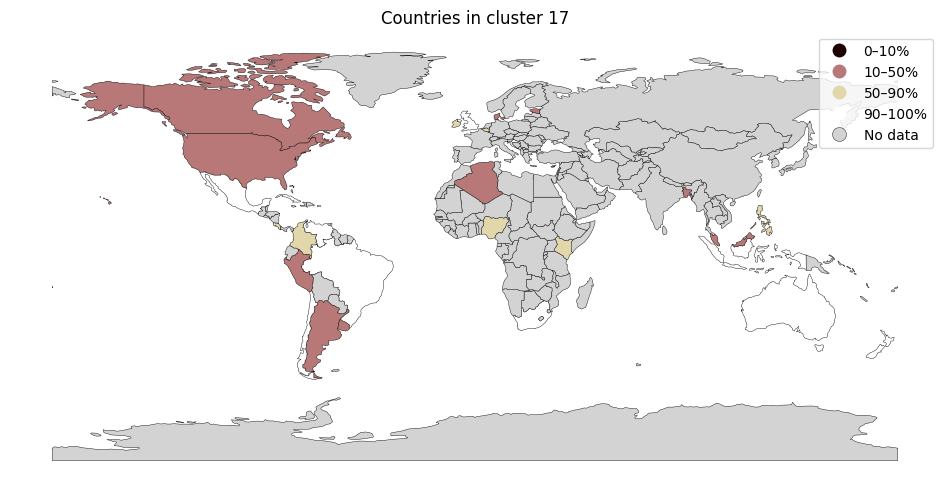

In [38]:
# --- 4. Merge with world map ---
world = world_url.merge(
    df_cluster_country_count,
    left_on="ISO_A3",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="year_cat",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Countries in cluster {cluster}")

plt.show()

In [39]:
n_countries_global = df_map_analysis.groupby(["year"], as_index=True).nunique().country.loc[years_list]
n_countries_cluster = df_map_analysis.query("cluster == @cluster").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
std = df_baricenter_global_yearly.std()

mult = 1 / np.sqrt(
    pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
    .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0))

In [40]:
df_spec = df_profile_yearly.xs(cluster, level=0).sub(df_baricenter_global_yearly.loc[years_list]).mul(mult.loc[years_list])

In [41]:
uf.plotly_heatmap(df_spec, df_spec.columns, df_spec.index, z_min=-100, z_max=100, x_type="subfield")

In [42]:
px.bar(df_spec.median().to_frame("cluster"), x=df_plot.mean().to_frame("cluster").index, y="cluster", hover_name=[uf.id2subfield_topic[int(sf)] for sf in df_spec.columns])

In [43]:
(
    df_spec
    .median()
    .to_frame("median_spec")
    .merge(uf.df_topics[["subfield_id", "field_name", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
           left_index=True, right_on="subfield_str")
    .groupby(["field_name", "domain_name"], as_index=False)
    # .groupby(["domain_name"], as_index=False)
    .median_spec
    .sum()
    .sort_values("median_spec")
    # .iloc[-1]
)

,field_name,domain_name,median_spec
17,Mathematics,Physical Sciences,-76.415644
4,Chemical Engineering,Physical Sciences,-58.496530
7,Decision Sciences,Social Sciences,-45.903289
19,Neuroscience,Life Sciences,-38.713919
21,"Pharmacology, Toxicology and Pharmaceutics",Life Sciences,-21.532585
11,Energy,Physical Sciences,-14.474962
16,Materials Science,Physical Sciences,-9.635937
12,Engineering,Physical Sciences,-0.606595
5,Chemistry,Physical Sciences,2.478343
25,Veterinary,Health Sciences,2.780123


In [44]:
n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()
std = df_baricenter_global_yearly.std()

In [48]:
cluster_spec_list = []
for cluster_loop in all_clusters:
    if cluster_loop == 0:
        continue
    years_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()

    n_countries_cluster = df_map_analysis.query("cluster == @cluster_loop").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    mult = 1 / np.sqrt(
        pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
        .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    # display(mult)
    tmp_dict = (
        df_profile_yearly
        .xs(cluster_loop, level=0)
        .sub(df_baricenter_global_yearly.loc[years_list])
        .mul(mult.loc[years_list])
        .median()
        .to_frame("median_spec")
        .merge(uf.df_topics[["subfield_id", "field_name", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
            left_index=True, right_on="subfield_str")
        # .groupby(["field_name", "domain_name"], as_index=False)
        .groupby(["domain_name"], as_index=False)
        .median_spec
        .sum()
        .sort_values("median_spec")
        .iloc[-1]
        .to_dict()
    )
    tmp_dict["cluster"] = cluster_loop
    cluster_spec_list.append(tmp_dict)
    if tmp_dict["median_spec"] == 0:
        print("NAN")
        # display(df_map_analysis.query("cluster == @cluster_loop"))
        display(
            df_profile_yearly
            .xs(cluster_loop, level=0)
            # .sub(df_baricenter_global_yearly.loc[years_list])
            # .mul(mult.loc[years_list])
            # # .median()
            # .to_frame("median_spec")
            # .merge(uf.df_topics[["subfield_id", "field_name", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
            #     left_index=True, right_on="subfield_str")
            # .groupby(["field_name", "domain_name"], as_index=False)
            # .median_spec
            # .sum()
            # .sort_values("median_spec")
            # .iloc[-1]
            # .to_dict()
        )
    # print()

df_cluster_spec = pd.json_normalize(cluster_spec_list).sort_values(["domain_name", "median_spec"])

In [49]:
min_median = df_cluster_spec.median_spec.min()
max_median = df_cluster_spec.median_spec.max()

In [50]:
df_cluster_spec

,domain_name,median_spec,cluster
20,Health Sciences,556.956524,27.0
22,Health Sciences,777.229667,25.0
17,Health Sciences,807.105061,22.0
9,Health Sciences,853.063471,13.0
28,Health Sciences,884.754758,33.0
27,Health Sciences,1048.248225,31.0
0,Health Sciences,1212.421878,8.0
2,Physical Sciences,407.507236,5.0
16,Physical Sciences,475.974707,21.0
6,Physical Sciences,476.045282,9.0


In [51]:
# RED = "#4E0000"
# BLUE = "#13273F"
# YELLOW = "#CB8E16"

BLUE = "#192741"
GREEN = "#404322"
ORANGE = "#AD4A18"
BRONZE = "#CE8A39"

In [52]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", color],
        N=n
    )

def truncate_cmap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


In [53]:
colors_domain = {
    "Physical Sciences": ORANGE,
    "Social Sciences": BLUE,
    "Health Sciences": GREEN,
    "Life Sciences": BRONZE
}

In [55]:
domain_list = df_cluster_spec.domain_name.unique()

color_dict_cluster = {
    -1: "white",
    0: "grey",
}

for domain_loop in domain_list:
    cmap = white_to_color(colors_domain[domain_loop])
    cmap = truncate_cmap(cmap, 0.2, 1.0)

    cluster_list = df_cluster_spec.query("domain_name == @domain_loop").cluster.to_list()

    # print(domain_loop, cluster_list)
    if len(cluster_list) == 1:
        color_list = [cmap(1.0)]
        # print(color_list)
    else:
        intensity = np.array([(val - min_median) / (max_median - min_median) for val in df_cluster_spec.query("domain_name == @domain_loop").median_spec])
        color_list = cmap(intensity)

    for i, cluster in enumerate(cluster_list):
        color_dict_cluster[cluster] = color_list[i]

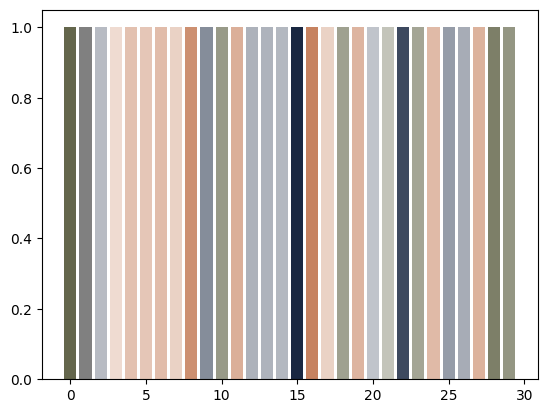

In [56]:
for i, cluster in enumerate(all_clusters):
    plt.bar(i, 1, color=color_dict_cluster[cluster], label=cluster)
# plt.legend()

In [57]:
names_dict_cluster = {
    -1: "Not analysed",
    0: "Undetermined",
}

count_dict = {}
for cluster_loop in df_cluster_spec.cluster:
    # print(cluster_loop)
    name = df_cluster_spec.query("cluster == @cluster_loop").iloc[0].domain_name
    if not (name in count_dict.keys()):
        count_dict[name] = 1
    else:
        count_dict[name] += 1
    names_dict_cluster[cluster_loop] = name+" "+str(count_dict[name])
    # print(df_cluster_spec.query("cluster == @cluster_loop").iloc[0].field_name)

In [58]:
df_stats_cluster

,year,cluster,country,countries_share,total_articles,total_articles_share,mean_distance,n_stayed
0,1975,0.0,2,0.009174,4088.0,0.004071,0.308008,NaN
1,1975,4.0,3,0.013761,23969.0,0.023872,0.464742,NaN
2,1975,5.0,15,0.068807,252015.0,0.250997,0.319602,NaN
3,1975,7.0,12,0.055046,694544.0,0.691738,0.297470,NaN
4,1975,8.0,5,0.022936,29440.0,0.029321,0.334074,NaN
...,...,...,...,...,...,...,...,...
224,2022,32.0,36,0.165138,2022438.0,0.110696,0.238017,31.0
225,2023,0.0,1,0.004587,763.0,0.000040,0.709143,1.0
226,2023,13.0,62,0.284404,14092986.0,0.741135,0.257452,58.0
227,2023,24.0,47,0.215596,2458617.0,0.129296,0.231199,45.0


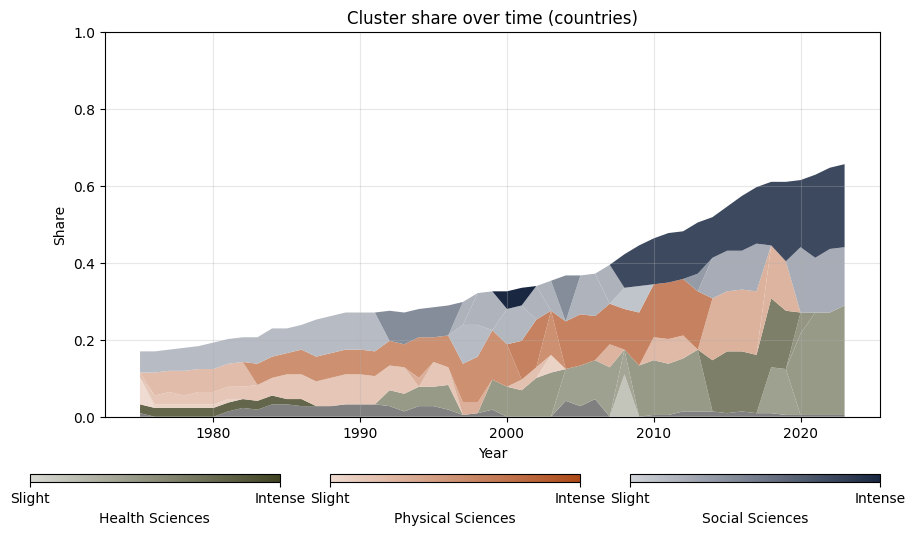

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. Ensure clusters are integers ---
df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# --- 2. Convert colors (matplotlib already OK, but normalize anyway) ---
# def to_mpl_color(c):
#     if isinstance(c, str):
#         return c
#     return mcolors.to_rgba(c)

# color_dict_cluster_mpl = {
#     k: to_mpl_color(v)
#     for k, v in color_dict_cluster.items()
# }

# --- 3. Add cluster names ---
df_plot = df_stats_cluster.copy()
df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# --- 4. Build color map with names ---
color_map_named = {
    names_dict_cluster[k]: color_dict_cluster[k]
    for k in color_dict_cluster
}
color_map_named["Undefined"] = "lightgrey"

# --- 5. Pivot to wide format ---
df_wide = (
    df_plot
    .pivot(index="year", columns="cluster_name", values="countries_share")
    .fillna(0)
)

# --- 6. Define consistent order ---
cluster_order = list(names_dict_cluster.values())

# keep only existing columns
cluster_order = [c for c in cluster_order if c in df_wide.columns]

df_wide = df_wide[cluster_order]

# --- 7. Plot stacked area ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.stackplot(
    df_wide.index,
    df_wide.T.values,
    labels=df_wide.columns,
    colors=[color_map_named[c] for c in df_wide.columns]
)

# --- 8. Styling ---
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Share")
ax.set_title("Cluster share over time (countries)")

# ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.05 + 0.05 * i + 0.25 * i, -0.02, 0.25, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(domain)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])


# plt.tight_layout()
plt.show()

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_4990/1802961370.py:78: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



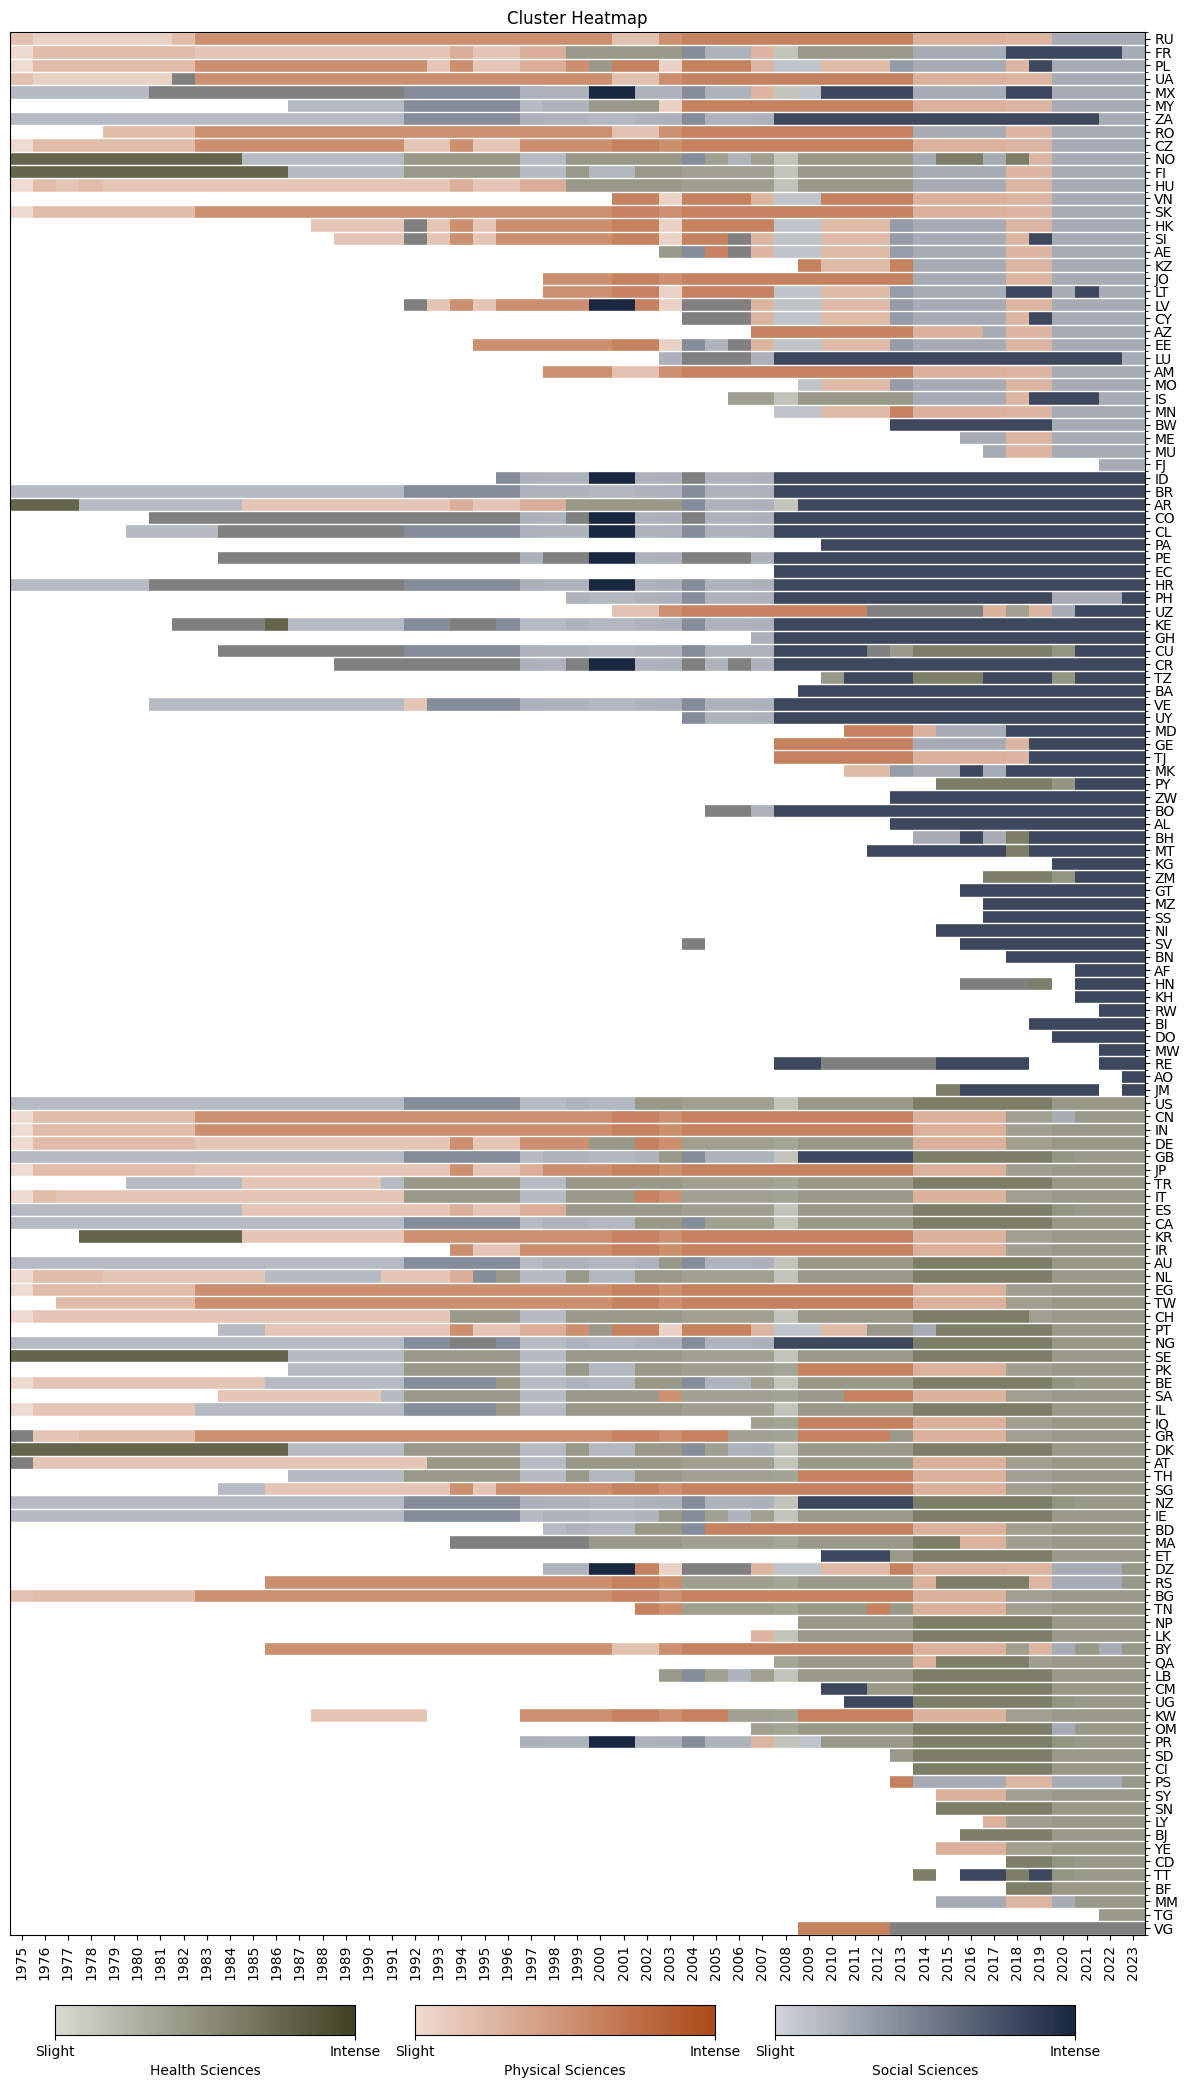

In [83]:
year = 2023
y_label = (
    df_map_analysis
    .merge(df_cs_yearly.sum(axis=1).to_frame("total"), left_on=["country", "year"], right_index=True)
    .query("year == @year").sort_values(["cluster", "total"], ascending=False)
    .country
    .to_list()
)

df_plot = (
    df_map_analysis
    .pivot(index="country", columns="year", values="cluster")
    .loc[y_label]
)
# --- 1. Map clusters to indices ---
clusters = sorted(color_dict_cluster.keys())
clusters_with_missing = clusters

color_list = [color_dict_cluster[cl] for cl in clusters_with_missing]
cmap = mcolors.ListedColormap(color_list)

# --- 5. Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 20))

cluster_to_idx = {c: i for i, c in enumerate(clusters)}

im = ax.imshow(
    df_plot.fillna(-1).replace(cluster_to_idx).values,
    aspect="auto",
    cmap=cmap,
)

# --- 6. Axis labels ---
ax.set_xticks(range(len(df_plot.columns)))
ax.set_xticklabels(df_plot.columns, rotation=90)

ax.set_yticks(range(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

ax.set_title("Cluster Heatmap")

from matplotlib.patches import Patch

# legend_elements = []

# for c in color_dict_cluster.keys():
#     legend_elements.append(Patch(facecolor=color_dict_cluster[c], label=names_dict_cluster[c]))

# ax.legend(
#     handles=legend_elements,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.04),
#     ncol=5,
#     fontsize=10
# )
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

n_rows, n_cols = df_plot.shape
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", axis="y", color="white", linewidth=1)
ax.tick_params(which="minor", left=False)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.05 + 0.05 * i + 0.25 * i, -0.02, 0.25, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(domain)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])

plt.tight_layout()
plt.show()